# Business Understanding

## Project Domain

Bisnis restoran adalah kegiatan usaha yang bergerak di bidang penyediaan makanan dan minuman untuk dikonsumsi langsung di tempat atau dibawa pulang. Restoran tidak hanya fokus pada penyajian makanan, tetapi juga pelayanan, suasana, dan pengalaman pelanggan.

domain : Bidang Usaha: Kuliner / F&B (Food and Beverage)
Lingkup: Penyediaan makanan dan minuman siap saji dengan layanan makan di tempat, take away, atau delivery.
Target Pasar: Konsumen individu, keluarga, dan kelompok yang mencari makanan dengan cita rasa khas, harga terjangkau, dan pelayanan memuaskan.

## Problem Statements

Banyak orang tidak memiliki waktu atau keterampilan untuk memasak sendiri di rumah.

Kurangnya restoran dengan harga terjangkau namun tetap menjaga kualitas dan kebersihan makanan.

Persaingan restoran yang tinggi menyebabkan sulitnya mempertahankan pelanggan.

Beberapa restoran gagal memberikan pelayanan yang konsisten dan memuaskan.

## Goals

Menyediakan makanan yang lezat, higienis, dan terjangkau bagi konsumen.

Menciptakan suasana nyaman yang membuat pelanggan ingin kembali.

Membangun citra restoran yang baik dan memiliki pelanggan setia.

Mengoptimalkan sistem operasional agar pelayanan lebih cepat dan efisien.

## Solution Statements

Menyusun menu yang variatif dengan bahan berkualitas dan harga kompetitif.

Melatih staf untuk memberikan pelayanan ramah dan profesional.

Menggunakan sistem manajemen restoran digital untuk pemesanan, pembayaran, dan stok.

Mengadakan promosi rutin dan program loyalitas pelanggan.

# Data Understanding

## Import data dari kaggle

In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rifanpurnama","key":"0564e158fd7002dad0a6b6697056dfc1"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [6]:
!kaggle datasets download -d liyangng/restaurant-success-prediction

Dataset URL: https://www.kaggle.com/datasets/liyangng/restaurant-success-prediction
License(s): apache-2.0


In [7]:
!mkdir restaurant-success-prediction
!unzip restaurant-success-prediction.zip -d restaurant-success-prediction
!ls restaurant-success-prediction

Archive:  restaurant-success-prediction.zip
  inflating: restaurant-success-prediction/Restaurant_Success_Dataset.csv  
Restaurant_Success_Dataset.csv


## Import Library yang dibutuhkan

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.pipeline import Pipeline


from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

## Exploratory Data Analysis

In [9]:
df = pd.read_csv('restaurant-success-prediction.zip')

In [10]:
df.head()

,Restaurant_ID,City,Cuisine_Type,Average_Meal_Price,Seating_Capacity,Years_in_Business,Google_Rating,Social_Media_Followers,Weekend_Reservations,Staff_Count,Delivery_Service,Marketing_Budget,Health_Inspection_Score,Annual_Revenue,Success_Label
0,R0001,Houston,Japanese,49,95,1,3.2,48576,202,33,Yes,3530,59,289190,0
1,R0002,San Francisco,Japanese,30,49,11,3.5,23749,246,46,No,9024,52,58888,1
2,R0003,Chicago,Japanese,24,40,16,3.2,42165,286,32,No,8607,85,1842602,1
3,R0004,San Francisco,Japanese,42,53,18,3.3,27225,236,22,Yes,17126,87,485413,1
4,R0005,San Francisco,Indian,44,60,16,3.2,34858,242,18,Yes,18768,74,1051830,1


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Restaurant_ID            1000 non-null   object 
 1   City                     1000 non-null   object 
 2   Cuisine_Type             1000 non-null   object 
 3   Average_Meal_Price       1000 non-null   int64  
 4   Seating_Capacity         1000 non-null   int64  
 5   Years_in_Business        1000 non-null   int64  
 6   Google_Rating            1000 non-null   float64
 7   Social_Media_Followers   1000 non-null   int64  
 8   Weekend_Reservations     1000 non-null   int64  
 9   Staff_Count              1000 non-null   int64  
 10  Delivery_Service         1000 non-null   object 
 11  Marketing_Budget         1000 non-null   int64  
 12  Health_Inspection_Score  1000 non-null   int64  
 13  Annual_Revenue           1000 non-null   int64  
 14  Success_Label            

<ipython-input-12-d4c2539eeb74>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Success_Label', data=df, palette='viridis')


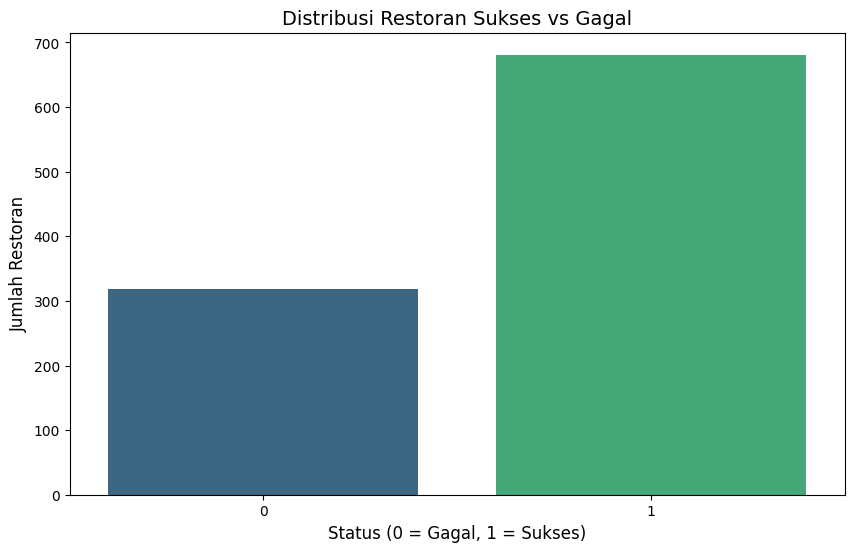

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Success_Label', data=df, palette='viridis')
plt.title('Distribusi Restoran Sukses vs Gagal', fontsize=14)
plt.xlabel('Status (0 = Gagal, 1 = Sukses)', fontsize=12)
plt.ylabel('Jumlah Restoran', fontsize=12)
plt.show()

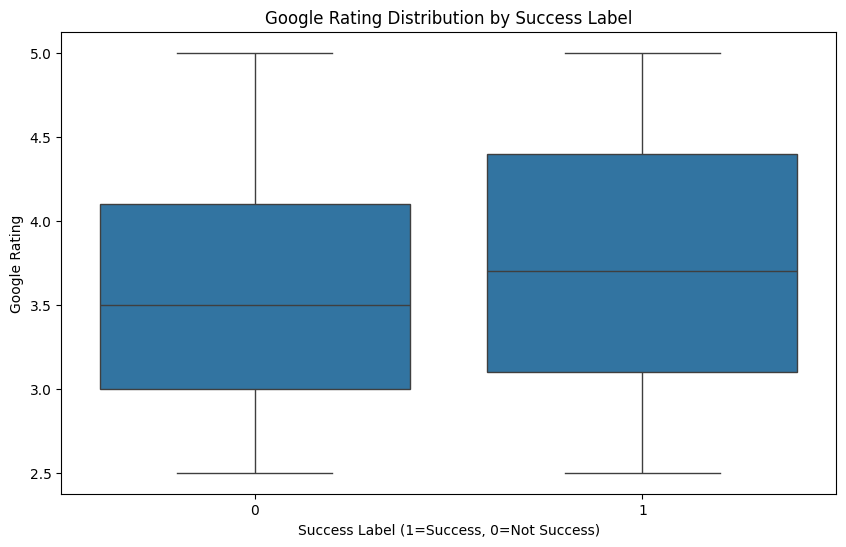

In [13]:
# 2. Distribusi Rating Google
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Success_Label', y='Google_Rating')
plt.title('Google Rating Distribution by Success Label')
plt.xlabel('Success Label (1=Success, 0=Not Success)')
plt.ylabel('Google Rating')
plt.show()

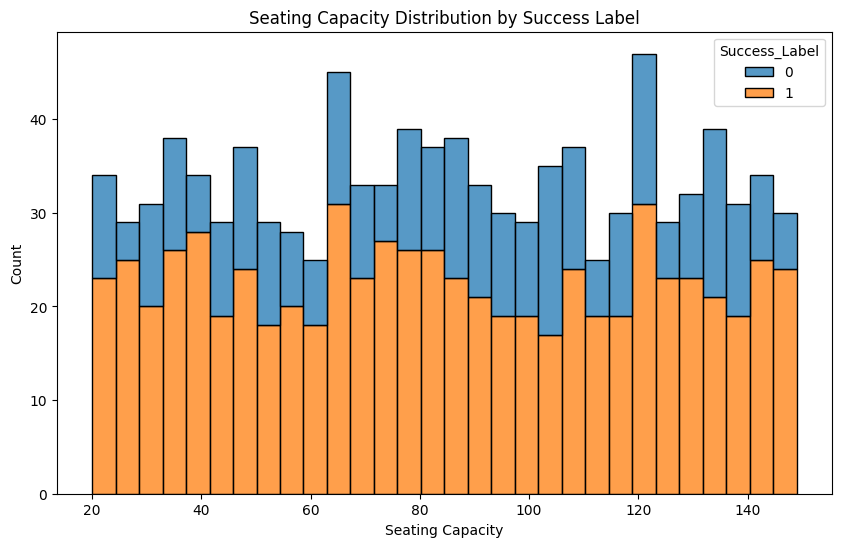

In [14]:
# 3. Hubungan antara Harga Rata-rata Makanan dan Kesuksesan
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Seating_Capacity', hue='Success_Label',
             multiple='stack', bins=30)
plt.title('Seating Capacity Distribution by Success Label')
plt.xlabel('Seating Capacity')
plt.ylabel('Count')
plt.show()

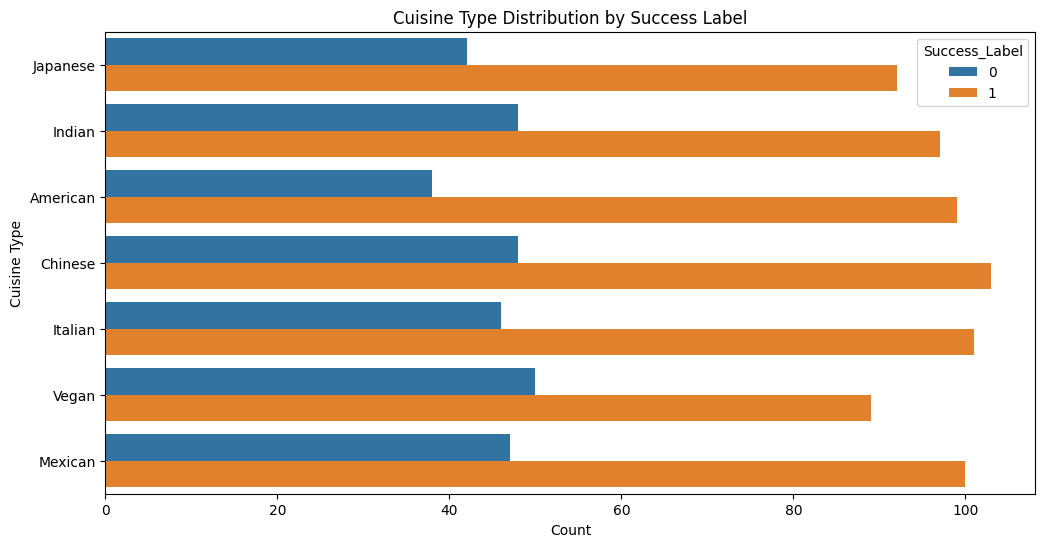

In [15]:
# 4. Persebaran Restoran Sukses per Kota
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='Cuisine_Type', hue='Success_Label')
plt.title('Cuisine Type Distribution by Success Label')
plt.xlabel('Count')
plt.ylabel('Cuisine Type')
plt.show()

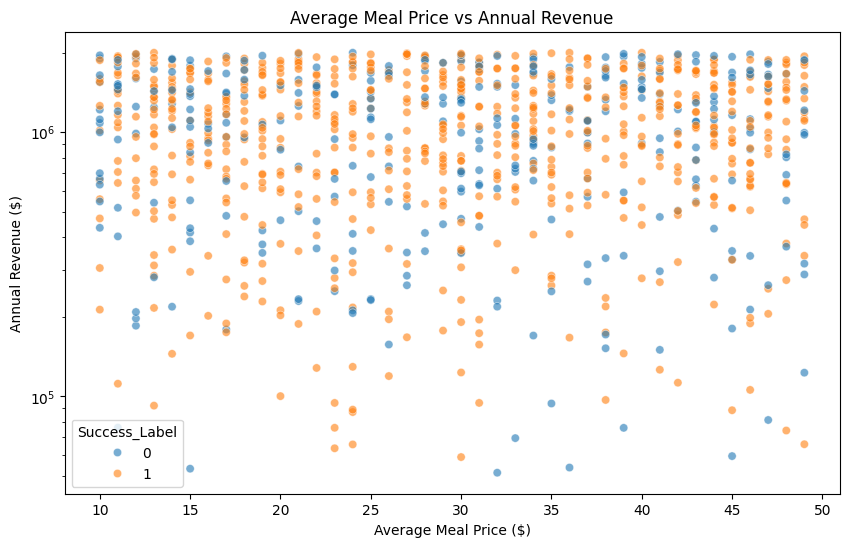

In [16]:
# 5. Korelasi antara Harga Rata-rata Makanan dengan Pendapatan Tahunan
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Average_Meal_Price', y='Annual_Revenue',
                hue='Success_Label', alpha=0.6)
plt.title('Average Meal Price vs Annual Revenue')
plt.xlabel('Average Meal Price ($)')
plt.ylabel('Annual Revenue ($)')
plt.yscale('log')
plt.show()

# Data Preparation

In [17]:
X = df.drop(columns=['Success_Label', 'Restaurant_ID'])  # Drop kolom yang tidak digunakan
y = df['Success_Label']

In [18]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [19]:
# 4. Normalisasi Fitur
# Identifikasi kolom numerik dan kategorikal
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Buat preprocessor untuk normalisasi
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),  # Normalisasi numerik [0,1]
        ('cat', 'passthrough', categorical_features)  # Kolom kategorikal tidak diubah
    ])

In [20]:
# One-hot encoding untuk fitur kategorikal
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

In [21]:
# Split data 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 800 samples
Test set size: 200 samples


In [22]:
# Inisialisasi scaler
scaler = StandardScaler()

# Fit dan transform data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform data test (tanpa fitting)
X_test_scaled = scaler.transform(X_test)

In [23]:
# Inisialisasi scaler
minmax_scaler = MinMaxScaler()

# Fit dan transform data training
X_train_minmax = minmax_scaler.fit_transform(X_train)

# Transform data test (tanpa fitting)
X_test_minmax = minmax_scaler.transform(X_test)

# Modeling

In [24]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [25]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,218 (51.63 KB)

 Trainable params: 13,218 (51.63 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Callback untuk early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

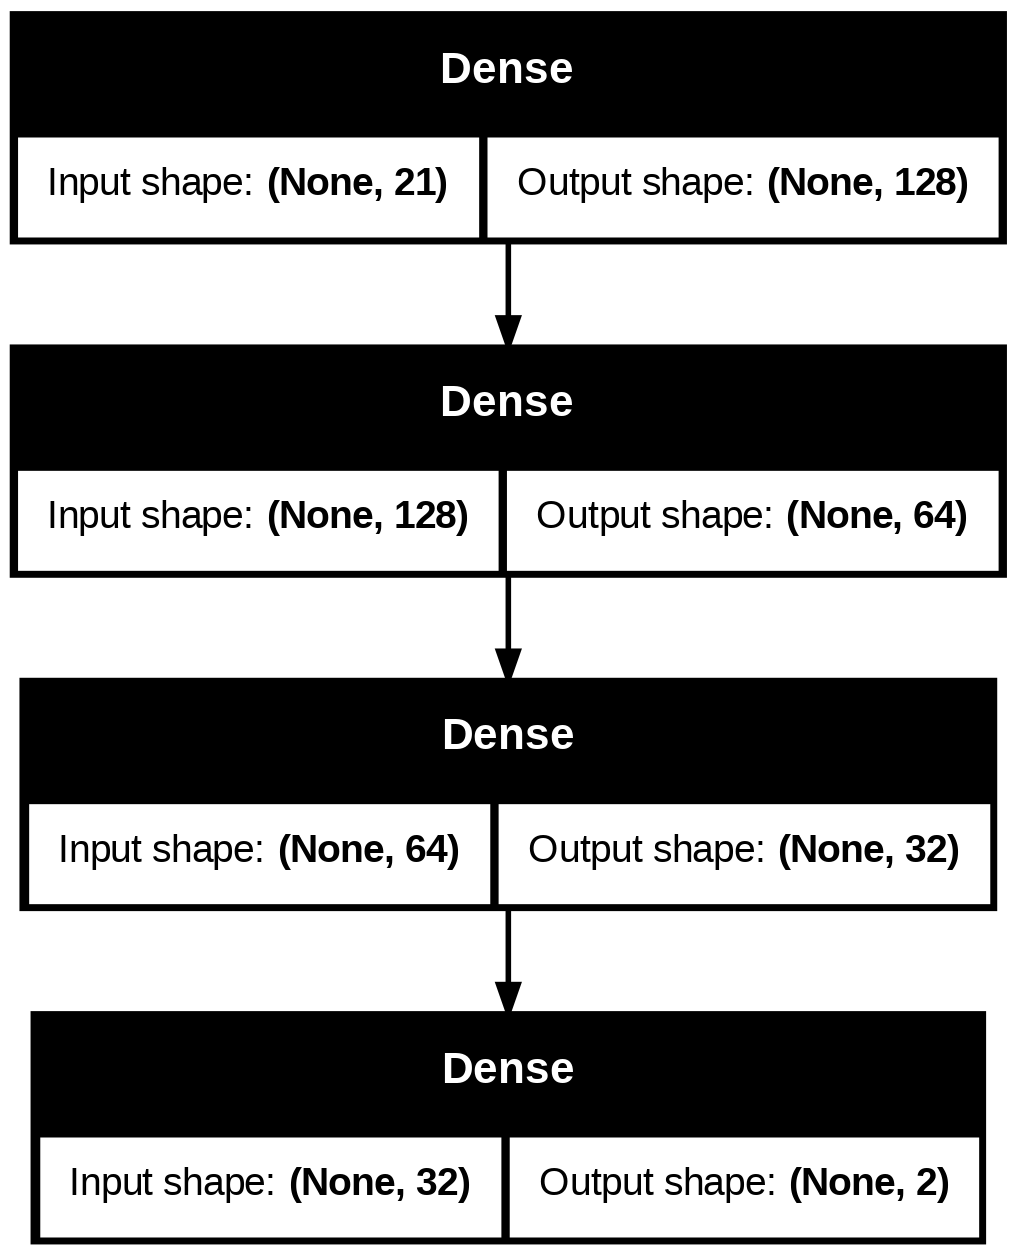

In [28]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [29]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6255 - loss: 7795.2461 - val_accuracy: 0.7550 - val_loss: 283.7288
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6668 - loss: 596.4422 - val_accuracy: 0.6850 - val_loss: 525.7709
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6787 - loss: 669.5859 - val_accuracy: 0.7850 - val_loss: 207.0271
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6791 - loss: 596.7480 - val_accuracy: 0.6800 - val_loss: 554.2389
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7045 - loss: 408.4563 - val_accuracy: 0.8000 - val_loss: 204.6162
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7037 - loss: 424.5975 - val_accuracy: 0.8000 - val_loss: 103.8359
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6964 - loss: 468.7552 - val_accuracy: 0.6800 - val_loss: 3234.2805
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6899 - loss: 978.0706 -

# Evaluation

In [30]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8793 - loss: 79.9462 

Test Accuracy: 0.8800
Test Loss: 82.5254


In [31]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

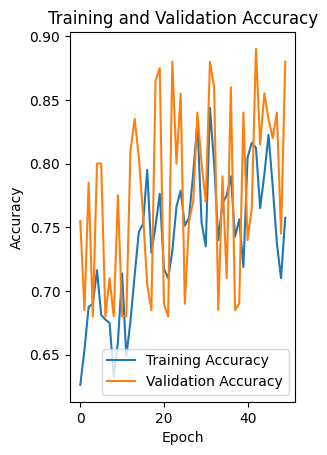

In [32]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

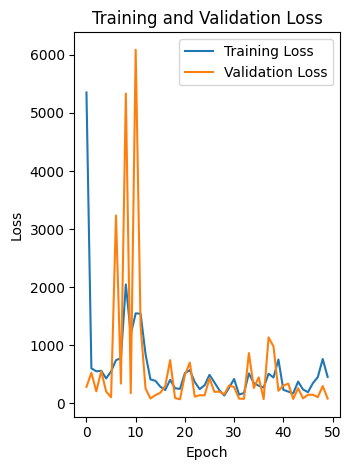

In [33]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


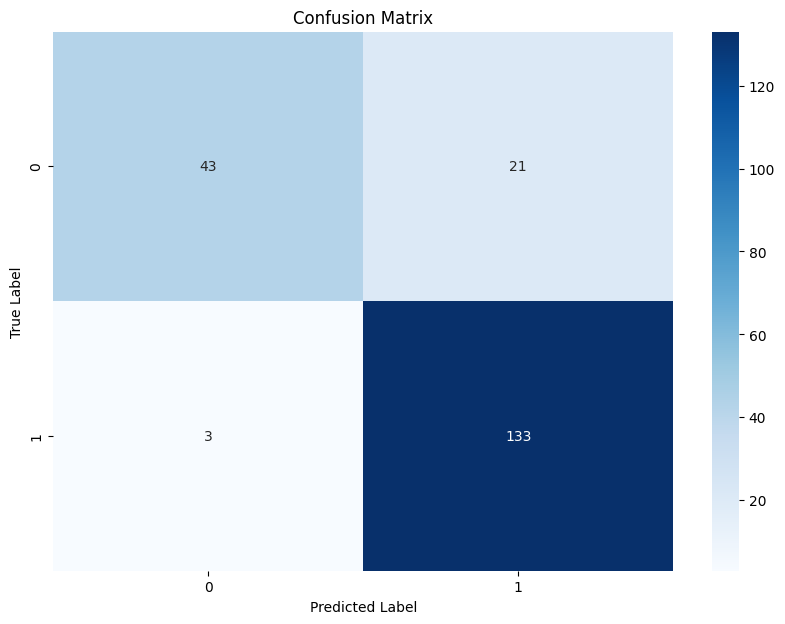

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.67      0.78        64
           1       0.86      0.98      0.92       136

    accuracy                           0.88       200
   macro avg       0.90      0.82      0.85       200
weighted avg       0.89      0.88      0.87       200



In [34]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [35]:
sample_input = {
    'City': ['Houston'],  # Kategorik
    'Cuisine_Type': ['Italian'],  # Kategorik
    'Average_Meal_Price': [42],  # Numerik
    'Seating_Capacity': [78],  # Numerik
    'Years_in_Business': [5],  # Numerik
    'Google_Rating': [4.2],  # Numerik
    'Social_Media_Followers': [12000],  # Numerik
    'Weekend_Reservations': [85],  # Numerik
    'Staff_Count': [15],  # Numerik
    'Delivery_Service': ['Yes'],  # Kategorik
    'Marketing_Budget': [15000],  # Numerik
    'Health_Inspection_Score': [88],  # Numerik
    'Annual_Revenue': [450000]  # Numerik
}
sample_input_df = pd.DataFrame(sample_input)

In [36]:
# 2. Konversi ke DataFrame
sample_df = pd.DataFrame(sample_input)

In [37]:
# Assuming 'X' is your original DataFrame before splitting
# Get all columns that were used during training (after one-hot encoding)
training_features = X.columns

# Create a new DataFrame with all training features and fill missing ones with 0
sample_input_df_full = pd.DataFrame(sample_input)
for feature in training_features:
    if feature not in sample_input_df_full.columns:
        sample_input_df_full[feature] = 0  # Fill with 0 for missing features

# Ensure the order of columns matches the training data
sample_input_df_full = sample_input_df_full[training_features]

# Now you can scale the data
sample_processed = scaler.transform(sample_input_df_full)

# Make the prediction
prediction = model.predict(sample_processed)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [38]:
prediction = model.predict(sample_processed)
predicted_success = "Sukses" if prediction[0][0] > 0.5 else "Gagal"
confidence = prediction[0][0] if predicted_success == "Sukses" else 1 - prediction[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [39]:
# 5. Tampilkan hasil
print("\n=== Hasil Prediksi ===")
print(f"Input Restoran:")
print(sample_df.iloc[0].to_string())
print(f"\nPrediksi: {predicted_success}")
print(f"Tingkat Kepercayaan: {confidence*100:.2f}%")

if predicted_success == "Sukses":
    print("\nRekomendasi: Restoran ini memiliki potensi sukses tinggi")
else:
    print("\nRekomendasi: Perlu evaluasi faktor-faktor penentu kesuksesan")


=== Hasil Prediksi ===
Input Restoran:
City                       Houston
Cuisine_Type               Italian
Average_Meal_Price              42
Seating_Capacity                78
Years_in_Business                5
Google_Rating                  4.2
Social_Media_Followers       12000
Weekend_Reservations            85
Staff_Count                     15
Delivery_Service               Yes
Marketing_Budget             15000
Health_Inspection_Score         88
Annual_Revenue              450000

Prediksi: Sukses
Tingkat Kepercayaan: 71.98%

Rekomendasi: Restoran ini memiliki potensi sukses tinggi


## Save Model

In [40]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('Restaurant_recommendation.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp50zds2zq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 21), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  135986596043984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596045136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596043408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596041872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596045712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596042064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596046096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135986596044944: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [41]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']